In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional scientific aesthetic style
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11, 
    'axes.labelsize': 12, 
    'axes.titlesize': 13, 
    'figure.titlesize': 14
})

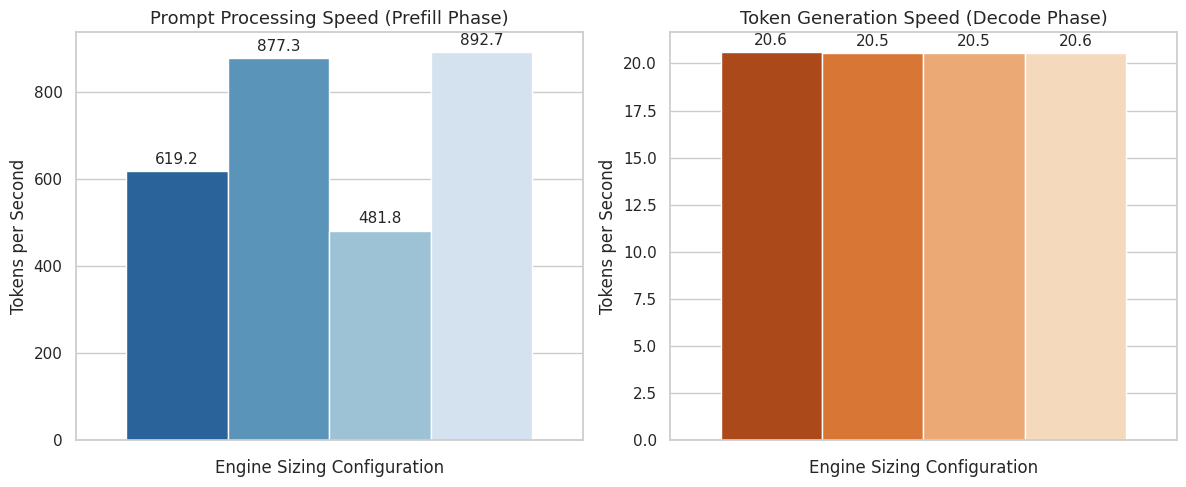

Batch Size Evaluation Summary


,Batch Size (n_batch),Micro-Batch (n_ubatch),Phase,Evaluation Load,Processing Speed (Tokens/s)
0,512,128,Prefill (Prompt),1024 tokens,481.844988
2,512,512,Prefill (Prompt),1024 tokens,892.653780
4,2048,128,Prefill (Prompt),1024 tokens,619.153790
6,2048,512,Prefill (Prompt),1024 tokens,877.346008
1,512,128,Decode (Generation),128 tokens,20.525617
3,512,512,Decode (Generation),128 tokens,20.569240
5,2048,128,Decode (Generation),128 tokens,20.617926
7,2048,512,Decode (Generation),128 tokens,20.549379


In [2]:
# Batch Size Evaluation Plots
df_batch = pd.read_csv('../advanced_benchmark_results/batch_size_evaluation.csv')
df_batch['config'] = 'Batch:' + df_batch['n_batch'].astype(str) + '\nMicroB:' + df_batch['n_ubatch'].astype(str)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
df_prompt = df_batch[df_batch['n_prompt'] > 0].sort_values('config')
df_gen = df_batch[df_batch['n_gen'] > 0].sort_values('config')

sns.barplot(data=df_prompt, hue='config', y='avg_ts', ax=ax1, palette='Blues_r', legend=False)
ax1.set_title('Prompt Processing Speed (Prefill Phase)')
ax1.set_ylabel('Tokens per Second')
ax1.set_xlabel('Engine Sizing Configuration')
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.1f', padding=3)

sns.barplot(data=df_gen, hue='config', y='avg_ts', ax=ax2, palette='Oranges_r', legend=False)
ax2.set_title('Token Generation Speed (Decode Phase)')
ax2.set_ylabel('Tokens per Second')
ax2.set_xlabel('Engine Sizing Configuration')
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.1f', padding=3)

plt.tight_layout()
plt.savefig('batch_size_perf.png', dpi=150)
plt.show()

# Batch Size Evaluation Tables
print("Batch Size Evaluation Summary")
df_prompt = df_batch[df_batch['n_prompt'] > 0].copy()
df_prompt['Phase'] = 'Prefill (Prompt)'
df_prompt['Evaluation Load'] = df_prompt['n_prompt'].astype(str) + " tokens"

# Process token generation records (Decode)
df_gen = df_batch[df_batch['n_gen'] > 0].copy()
df_gen['Phase'] = 'Decode (Generation)'
df_gen['Evaluation Load'] = df_gen['n_gen'].astype(str) + " tokens"

# Merge and format columns
df_combined = pd.concat([df_prompt, df_gen])
table_df = df_combined[['n_batch', 'n_ubatch', 'Phase', 'Evaluation Load', 'avg_ts']].copy()
table_df.columns = ['Batch Size (n_batch)', 'Micro-Batch (n_ubatch)', 'Phase', 'Evaluation Load', 'Processing Speed (Tokens/s)']

# Sort for structured comparison (Prefill metrics first)
table_df = table_df.sort_values(by=['Phase', 'Batch Size (n_batch)', 'Micro-Batch (n_ubatch)'], ascending=[False, True, True])
table_df.head(10)

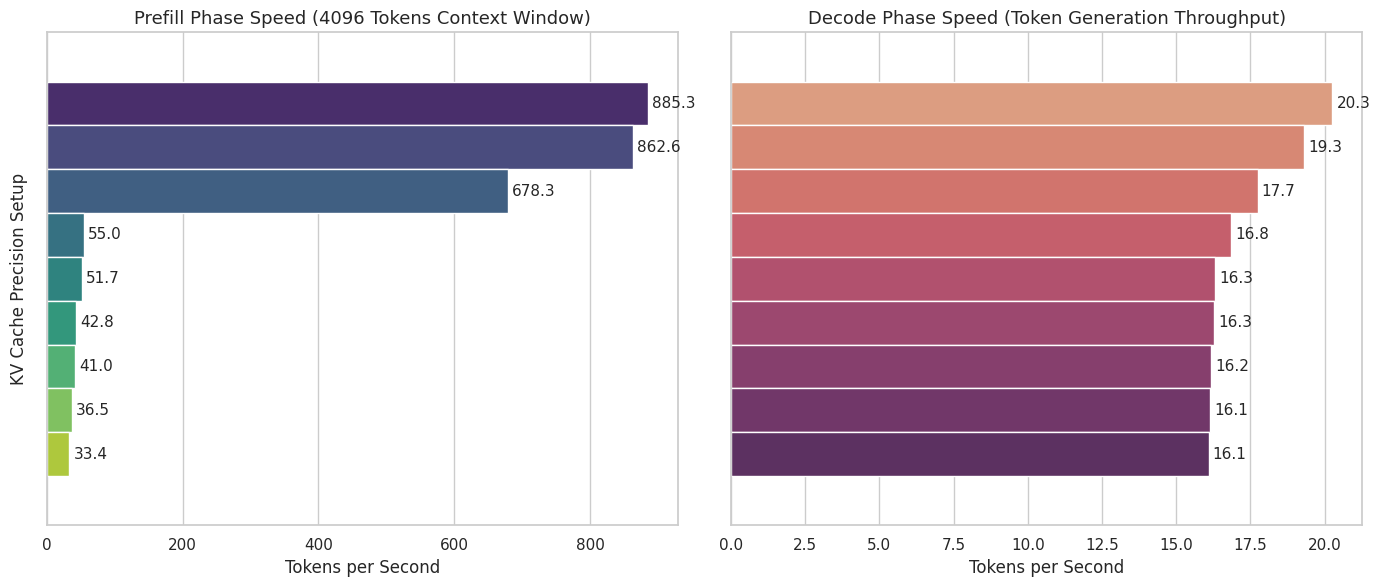

KV Cache Precision Tradeoff


,Key Cache Precision (type_k),Value Cache Precision (type_v),Prefill Phase Speed (Tokens/s),Decode Phase Speed (Tokens/s)
8,q8_0,q8_0,885.260023,19.300673
4,q4_0,q4_0,862.647248,20.260024
0,f16,f16,678.288868,17.738342
3,q4_0,f16,55.049561,16.837153
6,q8_0,f16,51.743587,16.125617
5,q4_0,q8_0,42.776523,16.271132
7,q8_0,q4_0,41.000415,16.314966
1,f16,q4_0,36.519822,16.182991
2,f16,q8_0,33.442302,16.087129


In [3]:
# KV Cache Tradeoff Plots
df_kv = pd.read_csv('../advanced_benchmark_results/kv_cache_tradeoff.csv')
df_kv['kv_combo'] = 'K: ' + df_kv['type_k'] + ' | V: ' + df_kv['type_v']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
df_kv_prompt = df_kv[df_kv['n_prompt'] > 0].sort_values('avg_ts', ascending=False)
df_kv_gen = df_kv[df_kv['n_gen'] > 0].sort_values('avg_ts', ascending=False)

#sns.barplot(data=df_kv_prompt, x='avg_ts', y='kv_combo', ax=ax1, palette='viridis')
sns.barplot(data=df_kv_prompt, x='avg_ts', hue='kv_combo', ax=ax1, palette='viridis', legend=False)
ax1.set_title('Prefill Phase Speed (4096 Tokens Context Window)')
ax1.set_xlabel('Tokens per Second')
ax1.set_ylabel('KV Cache Precision Setup')
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.1f', padding=3)

# sns.barplot(data=df_kv_gen, x='avg_ts', y='kv_combo', ax=ax2, palette='flare')
sns.barplot(data=df_kv_gen, x='avg_ts', hue='kv_combo', ax=ax2, palette='flare', legend=False)
ax2.set_title('Decode Phase Speed (Token Generation Throughput)')
ax2.set_xlabel('Tokens per Second')
ax2.set_ylabel('')
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.1f', padding=3)

plt.tight_layout()
plt.savefig('kv_cache_perf.png', dpi=150)
plt.show()

# KV Cache Tradeoff Tables
print("KV Cache Precision Tradeoff")
df_prompt = df_kv[df_kv['n_prompt'] > 0][['type_k', 'type_v', 'avg_ts']].rename(columns={'avg_ts': 'Prefill Phase Speed (Tokens/s)'})
df_gen = df_kv[df_kv['n_gen'] > 0][['type_k', 'type_v', 'avg_ts']].rename(columns={'avg_ts': 'Decode Phase Speed (Tokens/s)'})

# Align prefill and decode metrics horizontally by precision settings
table_df = pd.merge(df_prompt, df_gen, on=['type_k', 'type_v'], how='outer')
table_df.columns = ['Key Cache Precision (type_k)', 'Value Cache Precision (type_v)', 'Prefill Phase Speed (Tokens/s)', 'Decode Phase Speed (Tokens/s)']

# Rank configurations by raw processing velocity descending
table_df = table_df.sort_values(by='Prefill Phase Speed (Tokens/s)', ascending=False)
table_df.head(100)

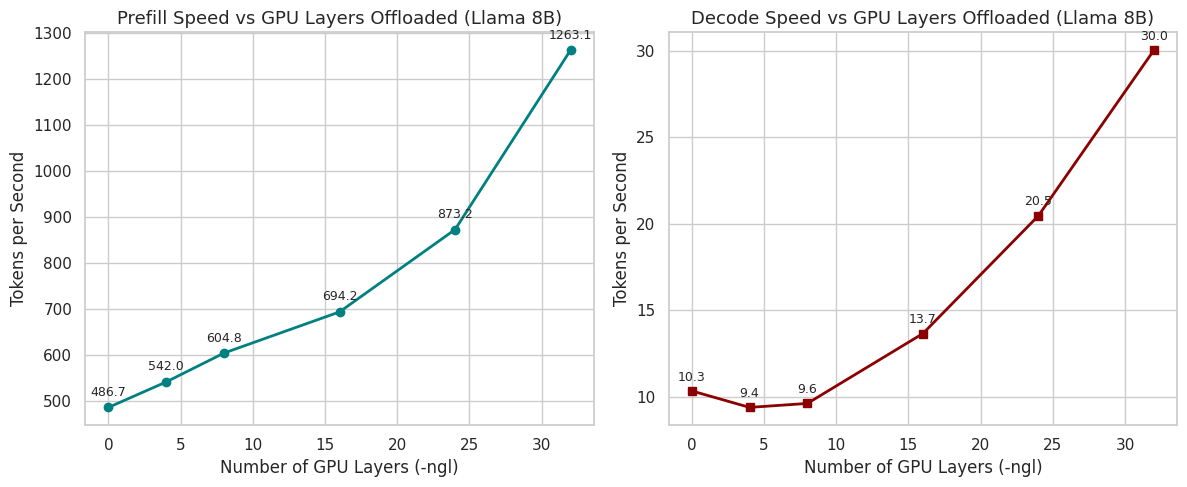

GPU Layer Offloading (-ngl) Curve


,Offloaded Layers (-ngl),Prefill Phase Speed (Tokens/s),Decode Phase Speed (Tokens/s)
0,0,486.655300,10.349030
1,4,542.030050,9.399670
2,8,604.784444,9.628344
3,16,694.182377,13.662375
4,24,873.188748,20.465209
5,32,1263.112143,30.025495


In [4]:
# GPU Layer Offloading Plots
df_ngl = pd.read_csv('../advanced_benchmark_results/ngl_test_8b.csv')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

df_ngl_prompt = df_ngl[df_ngl['n_prompt'] > 0].sort_values('n_gpu_layers')
df_ngl_gen = df_ngl[df_ngl['n_gen'] > 0].sort_values('n_gpu_layers')

ax1.plot(df_ngl_prompt['n_gpu_layers'], df_ngl_prompt['avg_ts'], marker='o', color='teal', linewidth=2)
ax1.set_title('Prefill Speed vs GPU Layers Offloaded (Llama 8B)')
ax1.set_xlabel('Number of GPU Layers (-ngl)')
ax1.set_ylabel('Tokens per Second')
for x, y in zip(df_ngl_prompt['n_gpu_layers'], df_ngl_prompt['avg_ts']):
    ax1.text(x, y + 25, f'{y:.1f}', ha='center', fontsize=9)

ax2.plot(df_ngl_gen['n_gpu_layers'], df_ngl_gen['avg_ts'], marker='s', color='darkred', linewidth=2)
ax2.set_title('Decode Speed vs GPU Layers Offloaded (Llama 8B)')
ax2.set_xlabel('Number of GPU Layers (-ngl)')
ax2.set_ylabel('Tokens per Second')
for x, y in zip(df_ngl_gen['n_gpu_layers'], df_ngl_gen['avg_ts']):
    ax2.text(x, y + 0.6, f'{y:.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('ngl_scaling.png', dpi=150)
plt.show()

# GPU Layer Offloading Tables
print("GPU Layer Offloading (-ngl) Curve")
df_prompt = df_ngl[df_ngl['n_prompt'] > 0][['n_gpu_layers', 'avg_ts']].rename(columns={'avg_ts': 'Prefill Phase Speed (Tokens/s)'})
df_gen = df_ngl[df_ngl['n_gen'] > 0][['n_gpu_layers', 'avg_ts']].rename(columns={'avg_ts': 'Decode Phase Speed (Tokens/s)'})

table_df = pd.merge(df_prompt, df_gen, on='n_gpu_layers', how='outer')
table_df.columns = ['Offloaded Layers (-ngl)', 'Prefill Phase Speed (Tokens/s)', 'Decode Phase Speed (Tokens/s)']

# Step upward from 0 layers (Pure CPU) up to maximum VRAM offload limits
table_df = table_df.sort_values(by='Offloaded Layers (-ngl)')
table_df.head(100)

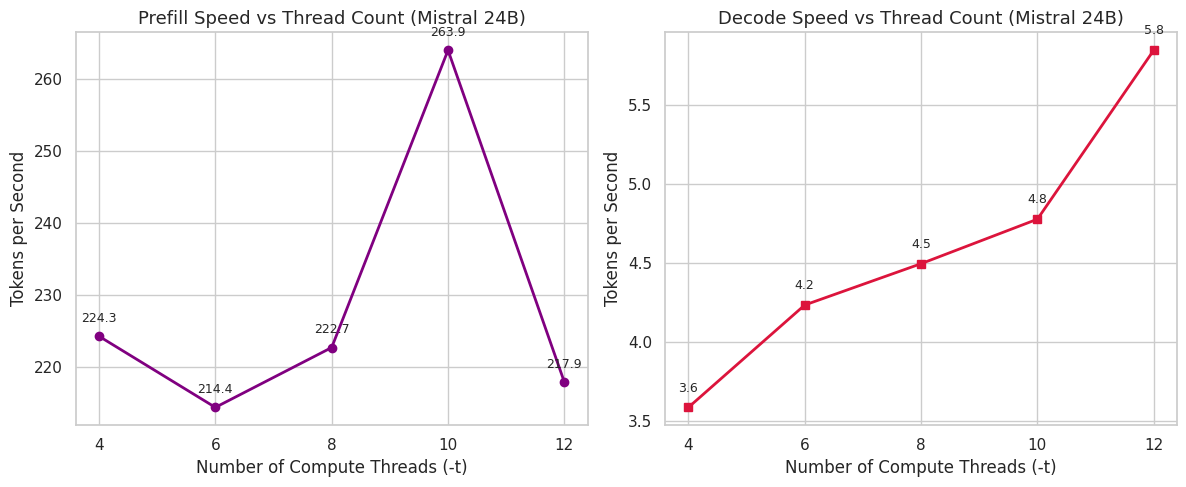

Thread Optimization Table


,Compute Thread Count (-t),Prefill Phase Speed (Tokens/s),Decode Phase Speed (Tokens/s)
0,4,224.262792,3.584186
1,6,214.395545,4.232035
2,8,222.700093,4.493643
3,10,263.939417,4.775291
4,12,217.905223,5.844779


In [5]:
# Thread Count Optimization Plots
df_thread = pd.read_csv('../advanced_benchmark_results/thread_optimization.csv')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

df_thread_prompt = df_thread[df_thread['n_prompt'] > 0].sort_values('n_threads')
df_thread_gen = df_thread[df_thread['n_gen'] > 0].sort_values('n_threads')

ax1.plot(df_thread_prompt['n_threads'], df_thread_prompt['avg_ts'], marker='o', color='purple', linewidth=2)
ax1.set_title('Prefill Speed vs Thread Count (Mistral 24B)')
ax1.set_xlabel('Number of Compute Threads (-t)')
ax1.set_ylabel('Tokens per Second')
ax1.set_xticks(df_thread_prompt['n_threads'])
for x, y in zip(df_thread_prompt['n_threads'], df_thread_prompt['avg_ts']):
    ax1.text(x, y + 2, f'{y:.1f}', ha='center', fontsize=9)

ax2.plot(df_thread_gen['n_threads'], df_thread_gen['avg_ts'], marker='s', color='crimson', linewidth=2)
ax2.set_title('Decode Speed vs Thread Count (Mistral 24B)')
ax2.set_xlabel('Number of Compute Threads (-t)')
ax2.set_ylabel('Tokens per Second')
ax2.set_xticks(df_thread_gen['n_threads'])
for x, y in zip(df_thread_gen['n_threads'], df_thread_gen['avg_ts']):
    ax2.text(x, y + 0.1, f'{y:.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('thread_perf.png', dpi=150)
plt.show()

# GPU Layer Offloading Tables
print("Thread Optimization Table")
df_prompt = df_thread[df_thread['n_prompt'] > 0][['n_threads', 'avg_ts']].rename(columns={'avg_ts': 'Prefill Phase Speed (Tokens/s)'})
df_gen = df_thread[df_thread['n_gen'] > 0][['n_threads', 'avg_ts']].rename(columns={'avg_ts': 'Decode Phase Speed (Tokens/s)'})

table_df = pd.merge(df_prompt, df_gen, on='n_threads', how='outer')
table_df.columns = ['Compute Thread Count (-t)', 'Prefill Phase Speed (Tokens/s)', 'Decode Phase Speed (Tokens/s)']

table_df = table_df.sort_values(by='Compute Thread Count (-t)')
table_df.head(100)